# **Notebook Final — Challenge Telecom X Parte 2**

# 1. Introducción

# Telecom X - Predicción de Cancelación (Churn)

En este proyecto se desarrollan modelos de Machine Learning para predecir la cancelación de clientes en Telecom X.

El objetivo es identificar qué clientes tienen mayor probabilidad de cancelar sus servicios, permitiendo a la empresa anticiparse al problema y aplicar estrategias de retención.

Este análisis incluye:

- Preparación de datos
- Análisis de correlación
- Entrenamiento de modelos de clasificación
- Evaluación de modelos
- Interpretación de variables
- Conclusiones estratégicas

#  2. Importación de librerías

In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# 3. Carga del dataset tratado

In [40]:
df = pd.read_csv("telecom_tratado.csv")

df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


# 4. Información general del dataset

In [41]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   int64  
 2   customer_gender            7032 non-null   object 
 3   customer_SeniorCitizen     7032 non-null   int64  
 4   customer_Partner           7032 non-null   object 
 5   customer_Dependents        7032 non-null   object 
 6   customer_tenure            7032 non-null   int64  
 7   phone_PhoneService         7032 non-null   object 
 8   phone_MultipleLines        7032 non-null   object 
 9   internet_InternetService   7032 non-null   object 
 10  internet_OnlineSecurity    7032 non-null   object 
 11  internet_OnlineBackup      7032 non-null   object 
 12  internet_DeviceProtection  7032 non-null   object 
 13  internet_TechSupport       7032 non-null   objec

,Churn,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,32.421786,64.798208,2283.300441
std,0.441782,0.368844,24.545260,30.085974,2266.771362
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,0.000000,0.000000,9.000000,35.587500,401.450000
50%,0.000000,0.000000,29.000000,70.350000,1397.475000
75%,1.000000,0.000000,55.000000,89.862500,3794.737500
max,1.000000,1.000000,72.000000,118.750000,8684.800000


# 5. Eliminación de columnas irrelevantes

In [42]:
df = df.drop(columns=["customerID"])

# 6. Encoding de variables categóricas

In [43]:
df = pd.get_dummies(df, drop_first=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 31 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Churn                                          7032 non-null   int64  
 1   customer_SeniorCitizen                         7032 non-null   int64  
 2   customer_tenure                                7032 non-null   int64  
 3   account_Charges_Monthly                        7032 non-null   float64
 4   account_Charges_Total                          7032 non-null   float64
 5   customer_gender_Male                           7032 non-null   bool   
 6   customer_Partner_Yes                           7032 non-null   bool   
 7   customer_Dependents_Yes                        7032 non-null   bool   
 8   phone_PhoneService_Yes                         7032 non-null   bool   
 9   phone_MultipleLines_No phone service           7032 

# 7. Proporción de cancelación (Churn)

In [44]:
df["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


Proporción:

In [45]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.734215
1,0.265785


Gráfico:

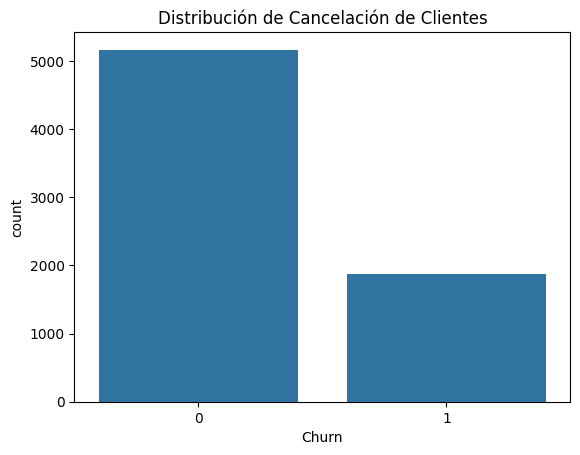

In [46]:
sns.countplot(x="Churn", data=df)
plt.title("Distribución de Cancelación de Clientes")
plt.show()

Clientes con menor tiempo de permanencia y cargos elevados presentan mayor probabilidad de cancelar el servicio.

Matriz de correlación

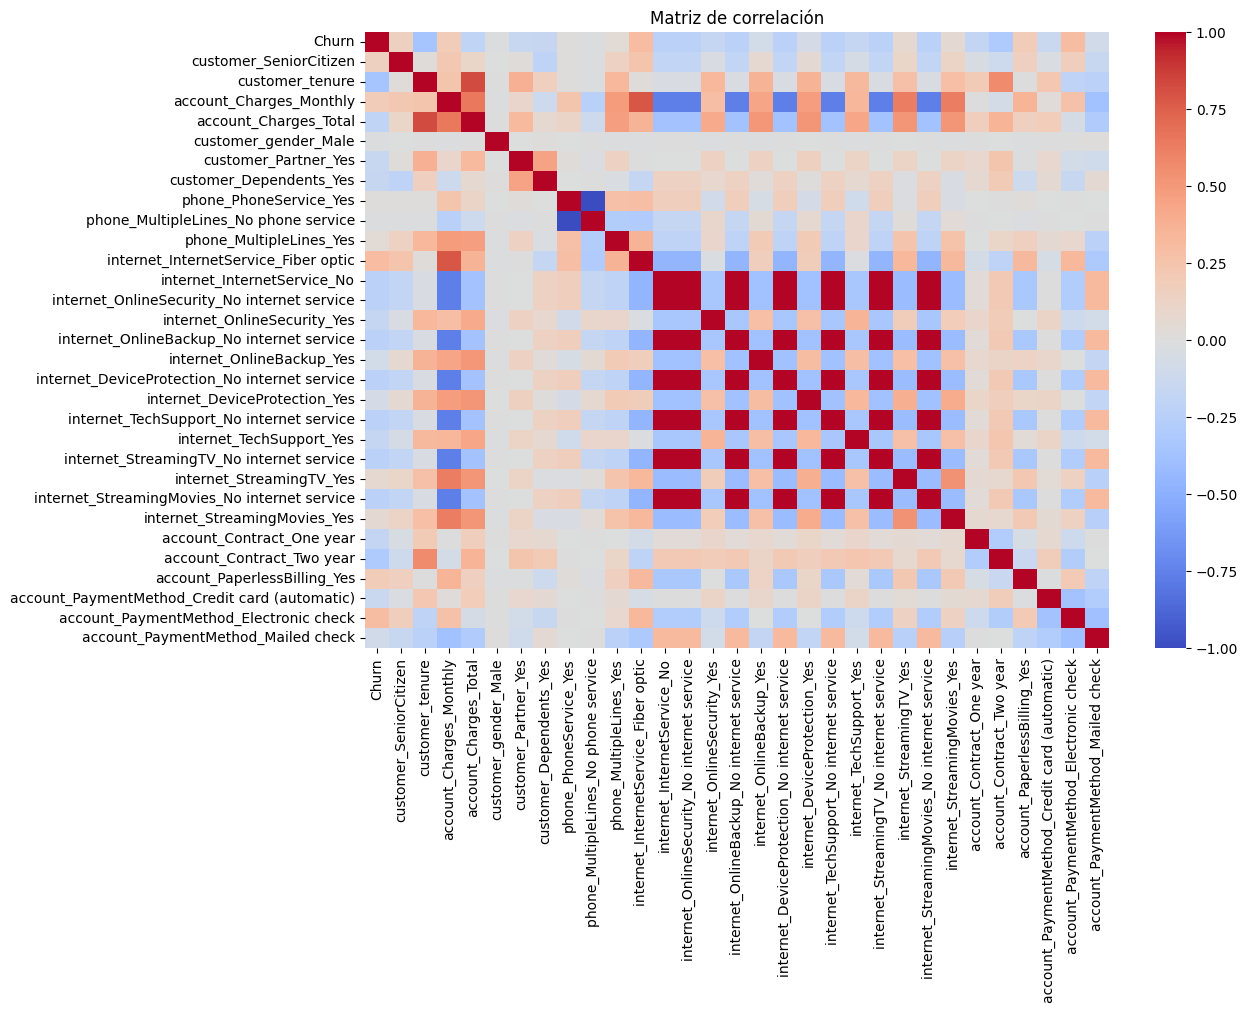

In [47]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

Análisis dirigido

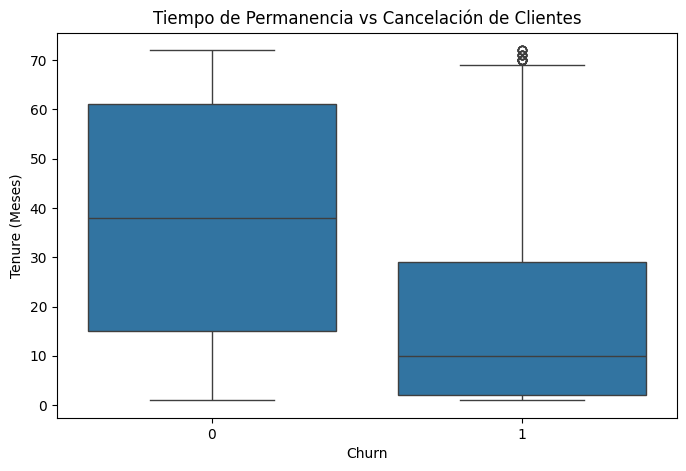

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="customer_tenure", data=df)

plt.title("Tiempo de Permanencia vs Cancelación de Clientes")
plt.xlabel("Churn")
plt.ylabel("Tenure (Meses)")

plt.show()

# 10. Separación de variables

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

# 11. División entrenamiento / prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 12. Normalización de datos

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 13. Modelo 1 — Regresión Logística

In [ ]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

# 14. Evaluación del modelo

In [ ]:
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

# 15. Modelo 2 — Random Forest

In [ ]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# 16. Evaluación Random Forest

In [ ]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Se comparan ambos modelos para evaluar cuál presenta mejor desempeño en términos de precisión, recall y F1-score.

## Comparación de modelos

Se compararon dos modelos de clasificación: Regresión Logística y Random Forest.

El modelo Random Forest presentó un mejor desempeño en las métricas de evaluación, especialmente en términos de F1-score y recall.

Esto indica que Random Forest logra capturar mejor las relaciones entre las variables del dataset y es más efectivo para identificar clientes con riesgo de cancelación.

# 17. Importancia de variables

In [ ]:
importances = rf_model.feature_importances_

features = pd.Series(importances, index=X.columns)

features.sort_values().plot(kind="barh", figsize=(10,8))
plt.title("Importancia de Variables")
plt.show()

Las variables con mayor importancia son aquellas que más contribuyen a la predicción de cancelación de clientes.

# 18. Conclusión estratégica

El análisis muestra que factores como el tipo de contrato, el tiempo de permanencia del cliente y los cargos mensuales influyen significativamente en la cancelación de clientes.

Los clientes con contratos mensuales y menor tiempo de permanencia presentan mayor probabilidad de cancelar sus servicios.

El modelo Random Forest presentó un desempeño superior en la predicción de churn, mostrando mejor capacidad para capturar patrones complejos en los datos.

## Recomendaciones para Telecom X

- Incentivar contratos de mayor duración.
- Implementar programas de fidelización para clientes nuevos.
- Ofrecer beneficios o descuentos a clientes con cargos mensuales elevados.

Estas acciones pueden ayudar a reducir la cancelación de clientes y mejorar la retención.